# Fashion-MNIST Classification Using TensorFlow

## Project Objective

The objective of this project is to design, train, and evaluate a deep neural network that classifies 28 × 28 grayscale Fashion-MNIST images into ten clothing categories. A baseline model and three controlled experiments are compared to study the effects of network capacity, dropout regularization, and learning rate. The target is to achieve at least 88% test accuracy while controlling overfitting and keeping the test set isolated until the final evaluation.

## Data Preparation and Exploration

Fashion-MNIST contains 60,000 official training images and 10,000 test images. The official training set was divided into 55,000 training examples and 5,000 validation examples using stratified sampling. Stratification preserves approximately the same class proportions in both subsets.

The test set was kept separate and was not used for architecture selection or hyperparameter tuning. Pixel values were converted from integers in the range [0, 255] to floating-point values in the range [0, 1]. Normalization improves numerical stability and supports more efficient neural-network optimization. Random seeds were also set to improve reproducibility.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

SEED = 42

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Class names corresponding to Fashion-MNIST labels
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Load the official training and test sets
(x_train_full, y_train_full), (x_test, y_test) = (keras.datasets.fashion_mnist.load_data())

# Normalize pixel values from [0, 255] to [0, 1]
x_train_full = x_train_full.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# Create stratified training and validation sets.
# The official test set remains untouched until final evaluation.
x_train, x_validation, y_train, y_validation = train_test_split(
    x_train_full,
    y_train_full,
    test_size=5000,
    random_state=SEED,
    stratify=y_train_full,)

print("Training set:" , x_train.shape, y_train.shape)
print("Validation set:" , x_validation.shape, y_validation.shape)
print("Test set:" , x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (55000, 28, 28) (55000,)
Validation set: (5000, 28, 28) (5000,)
Test set: (10000, 28, 28) (10000,)


First image shape: (28, 28)
First label number: 0
First label name: T-shirt/top


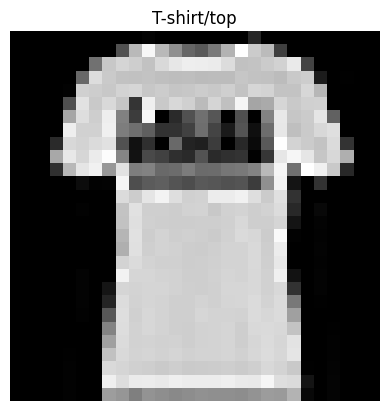

In [2]:
print("First image shape:", x_train[0].shape)
print("First label number:", y_train[0])
print("First label name:", CLASS_NAMES[y_train[0]])

plt.imshow(x_train[0],cmap="gray" )
plt.title(CLASS_NAMES[y_train[0]])
plt.axis("off")
plt.show()

### Representative Dataset Images

The following examples show representative Fashion-MNIST images together with their class labels. The images are low-resolution grayscale photographs, and several upper-body clothing categories have visually similar shapes. This similarity is expected to make classes such as T-shirt/top, Shirt, Pullover, and Coat more difficult to distinguish.

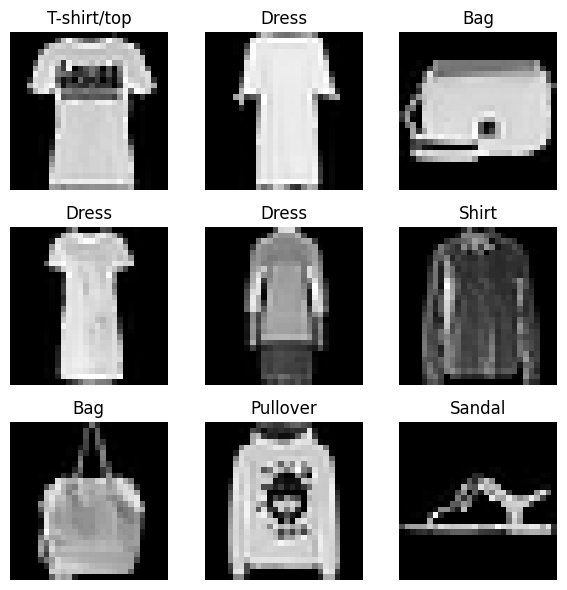

In [3]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(CLASS_NAMES[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Baseline Model

The baseline model establishes a simple reference for the controlled experiments. It consists of a Flatten layer, one hidden Dense layer with 128 ReLU units, and a ten-unit Softmax output layer.

ReLU was selected for the hidden layer because it is computationally efficient and helps neural networks learn nonlinear patterns. Softmax converts the final outputs into a probability distribution across the ten classes. Sparse categorical cross-entropy is appropriate because the problem is multiclass classification and the targets are stored as integer class labels. Adam with a learning rate of 0.001 was selected as a reliable adaptive optimizer.

All models are trained for 10 epochs with a batch size of 32 and the same training-validation split to maintain comparable experimental conditions.

In [4]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_validation, y_validation))

validation_loss, validation_accuracy = model.evaluate(
    x_validation,
    y_validation)

print("Validation loss:", validation_loss)
print("Validation accuracy:", validation_accuracy)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8209 - loss: 0.5095 - val_accuracy: 0.8726 - val_loss: 0.3635
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8627 - loss: 0.3823 - val_accuracy: 0.8846 - val_loss: 0.3293
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8753 - loss: 0.3410 - val_accuracy: 0.8874 - val_loss: 0.3145
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8846 - loss: 0.3149 - val_accuracy: 0.8922 - val_loss: 0.3034
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8918 - loss: 0.2944 - val_accuracy: 0.8926 - val_loss: 0.2957
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8969 - loss: 0.2792 - val_accuracy: 0.8916 - val_loss: 0.2940
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9025 - loss: 0.2652 - val_accuracy: 0.8942 - val_loss: 0.2938
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9071 - loss: 0.2533 

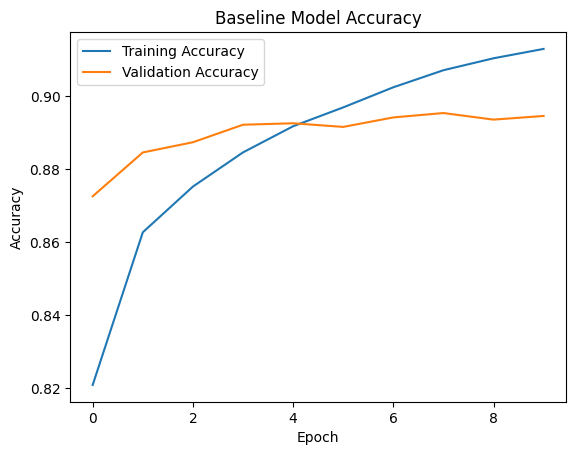

In [6]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

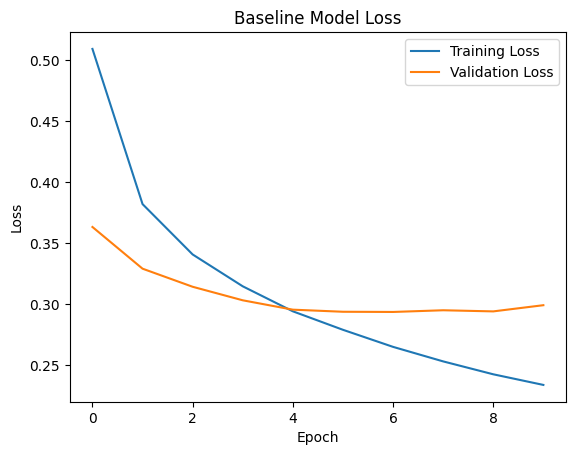

In [7]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Baseline Results

The baseline model contains 101,770 trainable parameters. After 10 epochs, it achieved approximately 91.30% training accuracy and 89.46% validation accuracy. The final generalization gap was approximately 1.84 percentage points.

Validation loss decreased during the early epochs but began to increase slightly near the end of training, while training accuracy continued to improve. This indicates mild overfitting. Nevertheless, the baseline provides a strong initial reference for evaluating the controlled architectural and training changes.

### Experiment 1: Increasing Network Capacity

The first controlled experiment examines the effect of increasing network depth and width. The baseline hidden layer was replaced with three Dense layers containing 256, 128, and 64 ReLU units. The optimizer, learning rate, loss function, batch size, number of epochs, and data split were kept unchanged.

The purpose of the decreasing layer sizes is to learn a high-capacity representation first and then progressively compress it before classification. This change increased the parameter count from 101,770 to 242,762, so the model has greater representational capacity but also requires more computation and has a higher risk of overfitting.

In [8]:
experiment1_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")])

experiment1_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

experiment1_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_exp1 = experiment1_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_validation, y_validation))

exp1_loss, exp1_accuracy = experiment1_model.evaluate(
    x_validation,
    y_validation)

print("Experiment 1 Validation Loss:", exp1_loss)
print("Experiment 1 Validation Accuracy:", exp1_accuracy)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8218 - loss: 0.4981 - val_accuracy: 0.8714 - val_loss: 0.3420
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8629 - loss: 0.3708 - val_accuracy: 0.8834 - val_loss: 0.3128
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8776 - loss: 0.3317 - val_accuracy: 0.8860 - val_loss: 0.3113
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8859 - loss: 0.3072 - val_accuracy: 0.8944 - val_loss: 0.2984
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8927 - loss: 0.2885 - val_accuracy: 0.8954 - val_loss: 0.2920
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8976 - loss: 0.2726 - val_accuracy: 0.8916 - val_loss: 0.3170
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9023 - loss: 0.2601 - val_accuracy: 0.8918 - val_loss: 0.2910
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9073 - loss: 0

In [10]:
baseline_gap = (
    history.history["accuracy"][-1]
    - history.history["val_accuracy"][-1])

exp1_gap = (
    history_exp1.history["accuracy"][-1]
    - history_exp1.history["val_accuracy"][-1])

print("Baseline generalization gap:", baseline_gap)
print("Experiment 1 generalization gap:", exp1_gap)

Baseline generalization gap: 0.018363654613494873
Experiment 1 generalization gap: 0.019509077072143555


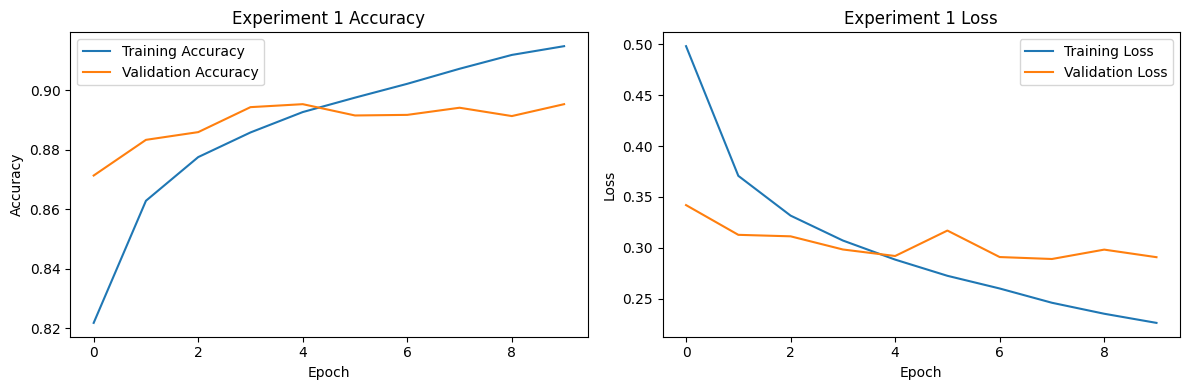

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    history_exp1.history["accuracy"],
    label="Training Accuracy"
)
axes[0].plot(
    history_exp1.history["val_accuracy"],
    label="Validation Accuracy"
)
axes[0].set_title("Experiment 1 Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(
    history_exp1.history["loss"],
    label="Training Loss"
)
axes[1].plot(
    history_exp1.history["val_loss"],
    label="Validation Loss"
)
axes[1].set_title("Experiment 1 Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Experiment 1 achieved 89.54% validation accuracy and a validation loss of 0.2908. Its final generalization gap was approximately 1.95 percentage points, compared with 1.84 percentage points for the baseline. Despite using 140,992 additional parameters, it improved validation accuracy by only 0.08 percentage points and produced a slightly larger generalization gap. This shows that increasing model capacity alone provided only a very small benefit while increasing computational cost and overfitting risk.

### Experiment 2: Dropout Regularization

Experiment 2 keeps the same Dense architecture as Experiment 1 and adds Dropout with a rate of 0.1 after each hidden layer. Dropout randomly disables 10% of the layer activations during training, reducing dependence on individual neurons and encouraging the network to learn more robust features.

Dropout does not add trainable parameters, so Experiment 2 retains 242,762 parameters. The main factor changed from Experiment 1 is regularization, allowing the effect of Dropout on generalization to be evaluated.

In [12]:
experiment2_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(10, activation="softmax")])

experiment2_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

experiment2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_exp2 = experiment2_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_validation, y_validation))

exp2_loss, exp2_accuracy = experiment2_model.evaluate(
    x_validation,
    y_validation)

print("Experiment 2 Validation Loss:", exp2_loss)
print("Experiment 2 Validation Accuracy:", exp2_accuracy)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8006 - loss: 0.5563 - val_accuracy: 0.8630 - val_loss: 0.3625
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8519 - loss: 0.4072 - val_accuracy: 0.8786 - val_loss: 0.3310
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8661 - loss: 0.3703 - val_accuracy: 0.8834 - val_loss: 0.3104
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8734 - loss: 0.3453 - val_accuracy: 0.8864 - val_loss: 0.3103
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8801 - loss: 0.3266 - val_accuracy: 0.8892 - val_loss: 0.3036
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8828 - loss: 0.3132 - val_accuracy: 0.8928 - val_loss: 0.2940
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8883 - loss: 0.3007 - val_accuracy: 0.8952 - val_loss: 0.2930
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8908 - loss: 0

In [14]:
exp2_gap = (
    history_exp2.history["accuracy"][-1]
    - history_exp2.history["val_accuracy"][-1])

print("Baseline generalization gap:", baseline_gap)
print("Experiment 1 generalization gap:", exp1_gap)
print("Experiment 2 generalization gap:", exp2_gap)

Baseline generalization gap: 0.018363654613494873
Experiment 1 generalization gap: 0.019509077072143555
Experiment 2 generalization gap: -0.00043636560440063477


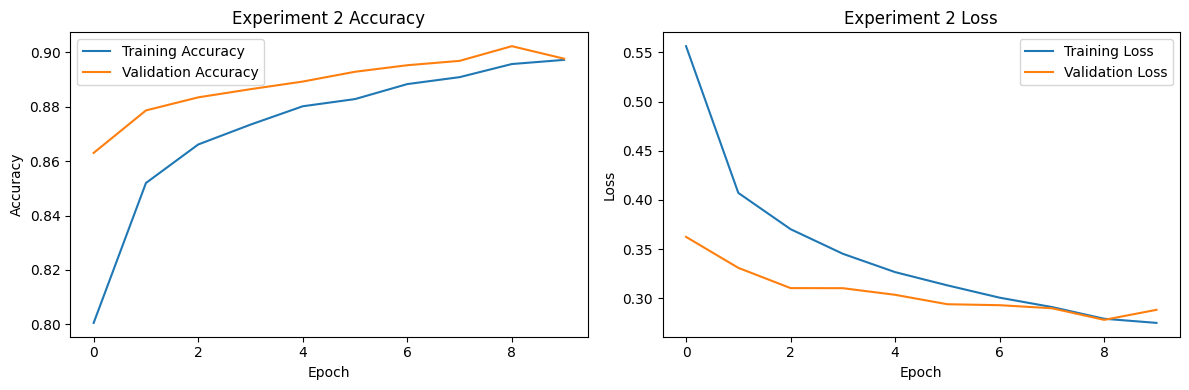

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    history_exp2.history["accuracy"],
    label="Training Accuracy"
)
axes[0].plot(
    history_exp2.history["val_accuracy"],
    label="Validation Accuracy"
)
axes[0].set_title("Experiment 2 Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(
    history_exp2.history["loss"],
    label="Training Loss"
)
axes[1].plot(
    history_exp2.history["val_loss"],
    label="Validation Loss"
)
axes[1].set_title("Experiment 2 Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Experiment 2 achieved 89.76% validation accuracy and a validation loss of 0.2883. Its final generalization gap was approximately -0.04 percentage points, compared with 1.95 percentage points in Experiment 1. The slightly negative gap means that validation accuracy was marginally higher than training accuracy, which can occur because Dropout is active during training but disabled during validation. These results show that Dropout substantially reduced overfitting and improved generalization.

### Experiment 3: Lower Learning Rate

Experiment 3 retains the architecture and Dropout settings from Experiment 2 but reduces the Adam learning rate from 0.001 to 0.0005. This is a controlled optimizer-setting experiment because the learning rate is the only main factor changed.

A smaller learning rate produces more conservative parameter updates. It may require more iterations to converge, but it can avoid overshooting a good solution and may produce more stable validation performance.

In [16]:
experiment3_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(10, activation="softmax")])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

experiment3_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

experiment3_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_exp3 = experiment3_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_validation, y_validation))

exp3_loss, exp3_accuracy = experiment3_model.evaluate(
    x_validation,
    y_validation)

print("Experiment 3 Validation Loss:", exp3_loss)
print("Experiment 3 Validation Accuracy:", exp3_accuracy)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7982 - loss: 0.5686 - val_accuracy: 0.8706 - val_loss: 0.3535
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8535 - loss: 0.4016 - val_accuracy: 0.8848 - val_loss: 0.3209
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8676 - loss: 0.3616 - val_accuracy: 0.8882 - val_loss: 0.3078
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8764 - loss: 0.3363 - val_accuracy: 0.8910 - val_loss: 0.2956
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8833 - loss: 0.3179 - val_accuracy: 0.8964 - val_loss: 0.2854
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8866 - loss: 0.3040 - val_accuracy: 0.8994 - val_loss: 0.2802
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8921 - loss: 0.2892 - val_accuracy: 0.8954 - val_loss: 0.2822
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8965 - loss: 0

In [18]:
exp3_gap = (
    history_exp3.history["accuracy"][-1]
    - history_exp3.history["val_accuracy"][-1])

print("Baseline generalization gap:", baseline_gap)
print("Experiment 1 generalization gap:", exp1_gap)
print("Experiment 2 generalization gap:", exp2_gap)
print("Experiment 3 generalization gap:", exp3_gap)

Baseline generalization gap: 0.018363654613494873
Experiment 1 generalization gap: 0.019509077072143555
Experiment 2 generalization gap: -0.00043636560440063477
Experiment 3 generalization gap: 0.0028545260429382324


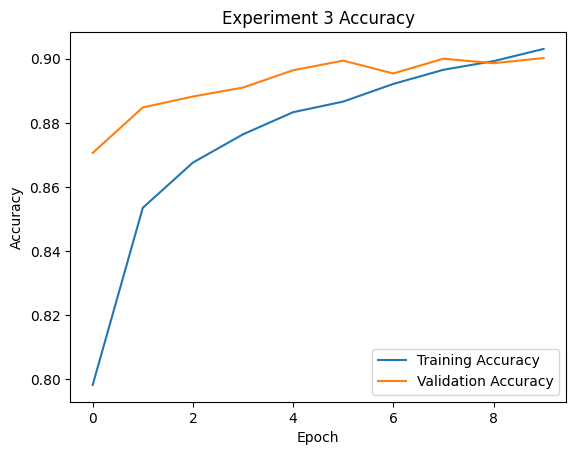

In [19]:
plt.plot(
    history_exp3.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_exp3.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Experiment 3 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

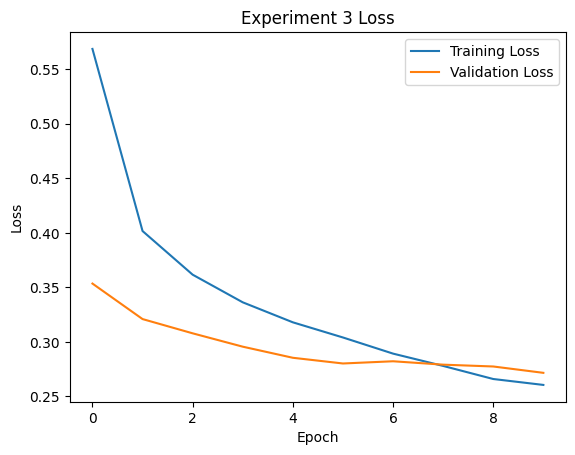

In [20]:
plt.plot(
    history_exp3.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_exp3.history["val_loss"],
    label="Validation Loss"
)

plt.title("Experiment 3 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Experiment 3 achieved the strongest validation result: 90.02% validation accuracy with a validation loss of 0.2716. Its final generalization gap was approximately 0.29 percentage points, which remains very small. The validation curves improved steadily, indicating stable convergence under the lower learning rate.

These results show that reducing the learning rate improved validation accuracy and validation loss relative to Experiment 2 without increasing the number of parameters. Therefore, Experiment 3 was selected as the final model.

## Final Test Evaluation

After completing model selection using validation results, the selected model was evaluated once on the untouched test set. This provides an unbiased estimate of its performance on unseen Fashion-MNIST images.

In [21]:
final_model = experiment3_model

test_loss, test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=0)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)

Final Test Loss: 0.32203221321105957
Final Test Accuracy: 0.8867999911308289


In [22]:
from sklearn.metrics import classification_report

y_probabilities = final_model.predict(x_test)
y_predictions = np.argmax(y_probabilities, axis=1)

print(classification_report(
        y_test,
        y_predictions,
        target_names=CLASS_NAMES,
        digits=4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

 T-shirt/top     0.8333    0.8200    0.8266      1000
     Trouser     0.9928    0.9660    0.9792      1000
    Pullover     0.8159    0.7800    0.7975      1000
       Dress     0.8927    0.8820    0.8873      1000
        Coat     0.7773    0.8340    0.8046      1000
      Sandal     0.9837    0.9650    0.9743      1000
       Shirt     0.7074    0.7060    0.7067      1000
     Sneaker     0.9498    0.9650    0.9573      1000
         Bag     0.9591    0.9840    0.9714      1000
  Ankle boot     0.9612    0.9660    0.9636      1000

    accuracy                         0.8868     10000
   macro avg     0.8873    0.8868    0.8869     10000
weighted avg     0.8873    0.8868    0.8869     10000



The final model achieved 88.68% test accuracy, exceeding the required 88% target. Its macro-average precision, recall, and F1-score were approximately 88.73%, 88.68%, and 88.69%, respectively. Because Fashion-MNIST contains the same number of test examples for each class, the macro and weighted averages are identical.

Trouser, Bag, Sandal, Sneaker, and Ankle boot achieved strong F1-scores above 0.95. Shirt was the most difficult class, with an F1-score of 0.7067. Pullover and Coat were also more difficult than footwear and accessory classes. This is consistent with the visual similarity among upper-body garments.

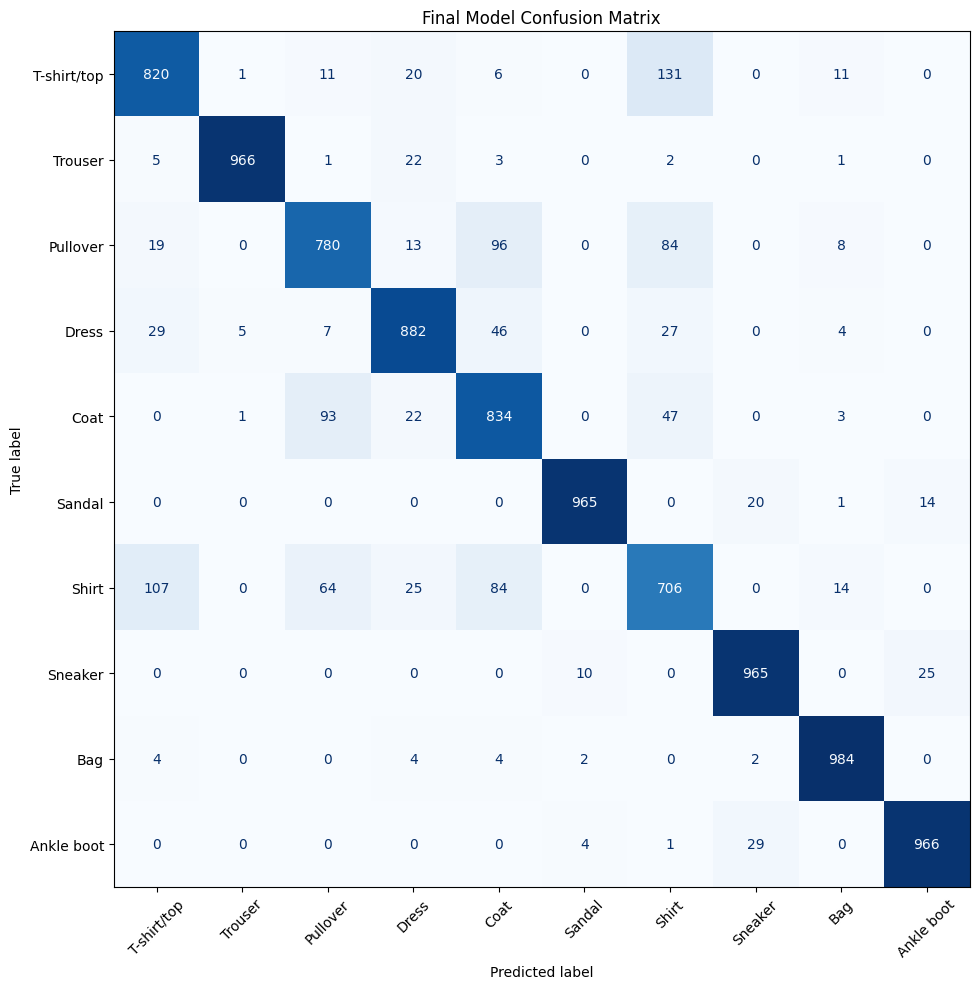

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 10))

display.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d",
    ax=ax,
    colorbar=False)

plt.title("Final Model Confusion Matrix")
plt.tight_layout()
plt.show()

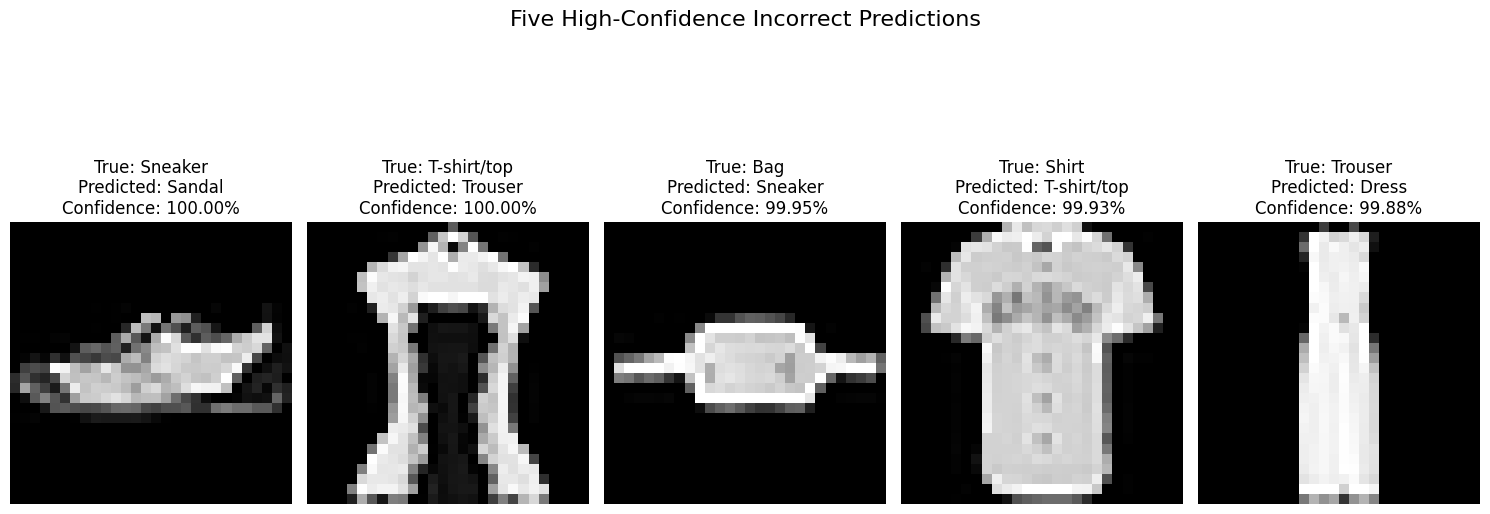

In [24]:
incorrect_indices = np.where(y_predictions != y_test)[0]

# Select the five incorrect predictions with highest confidence
incorrect_confidences = np.max(
    y_probabilities[incorrect_indices],
    axis=1
)

top_five_positions = np.argsort(
    incorrect_confidences
)[-5:][::-1]

selected_indices = incorrect_indices[top_five_positions]

plt.figure(figsize=(15, 7))

for i, image_index in enumerate(selected_indices):
    true_label = y_test[image_index]
    predicted_label = y_predictions[image_index]
    confidence = y_probabilities[
        image_index, predicted_label
    ]

    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[image_index], cmap="gray")
    plt.title(
        f"True: {CLASS_NAMES[true_label]}\n"
        f"Predicted: {CLASS_NAMES[predicted_label]}\n"
        f"Confidence: {confidence:.2%}"
    )
    plt.axis("off")

plt.suptitle(
    "Five High-Confidence Incorrect Predictions",
    fontsize=16)
plt.tight_layout()
plt.show()

## Error Analysis

Five high-confidence incorrect predictions are displayed above. These cases are especially informative because the model assigned a high probability to an incorrect class rather than being uncertain.

The classification report and confusion matrix show that the main errors occur among visually similar upper-body garments, particularly Shirt, T-shirt/top, Pullover, and Coat. These classes may share similar silhouettes, sleeves, and grayscale texture at the low 28 × 28 image resolution. In contrast, classes such as Bag, Trouser, and footwear have more distinctive shapes and are classified more accurately.

The incorrect examples demonstrate that confidence does not always indicate correctness. A model can make an incorrect prediction with high confidence when two classes contain similar visual features or when an image is ambiguous. Possible future improvements include using a convolutional neural network, data augmentation, learning-rate scheduling, and early stopping.

- **Image 1:** The true class was Dress, but the model predicted Bag with 100% confidence. The dark rectangular upper region and the light lower region may have created a compact shape resembling a bag.

- **Image 2:** The true class was Bag, but the model predicted Sneaker with 99.98% confidence. Its horizontal strap and elongated shape may resemble the outline of a shoe at the low image resolution.

- **Image 3:** The true class was Shirt, but the model predicted T-shirt/top with 99.98% confidence. Both classes have short sleeves and very similar upper-body silhouettes.

- **Image 4:** The true class was Shirt, but the model predicted T-shirt/top with 99.97% confidence. The short sleeves and T-shirt-like shape make the distinction between the two classes ambiguous.

- **Image 5:** The true class was Sneaker, but the model predicted Sandal with 99.95% confidence. The low-cut shape and visible light regions may have been interpreted as open sections typically associated with sandals.

## Model Saving and Inference

The best model is saved in the Keras (.keras) format. The saved model is then loaded and evaluated again to verify that serialization preserved its learned parameters and performance.

The inference function accepts one 28 × 28 image, normalizes it when necessary, adds a batch dimension, and returns the predicted class name and confidence score. This demonstrates how the trained model can be used on a new individual image.

In [25]:
final_model.save("best_model.keras")

print("Model saved successfully as best_model.keras")

Model saved successfully as best_model.keras


In [26]:
loaded_model = keras.models.load_model("best_model.keras")

loaded_loss, loaded_accuracy = loaded_model.evaluate(
    x_test,
    y_test,
    verbose=0)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

Loaded Model Test Loss: 0.32203221321105957
Loaded Model Test Accuracy: 0.8867999911308289


In [27]:
def predict_image(model, image):
    image = np.asarray(image, dtype=np.float32)

    # Normalize only if the image is not already normalized
    if image.max() > 1.0:
        image = image / 255.0

    image = np.expand_dims(image, axis=0)

    probabilities = model.predict(image, verbose=0)[0]
    predicted_label = np.argmax(probabilities)
    confidence = probabilities[predicted_label]

    return CLASS_NAMES[predicted_label], confidence

In [28]:
predicted_class, confidence = predict_image(
    loaded_model,
    x_test[0])

print("Predicted class:", predicted_class)
print("Confidence:", confidence)
print("True class:", CLASS_NAMES[y_test[0]])

Predicted class: Ankle boot
Confidence: 0.9964804
True class: Ankle boot


## Model Comparison and Final Model Selection

The models are compared using validation performance because the test set was reserved exclusively for the final evaluation. Experiment 3 was selected because it achieved the highest validation accuracy and the lowest validation loss while maintaining a small generalization gap.

In [29]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Model": [
        "Baseline",
        "Experiment 1",
        "Experiment 2",
        "Experiment 3"
    ],
    "Parameters": [
        model.count_params(),
        experiment1_model.count_params(),
        experiment2_model.count_params(),
        experiment3_model.count_params()
    ],
    "Validation Loss": [
        validation_loss,
        exp1_loss,
        exp2_loss,
        exp3_loss
    ],
    "Validation Accuracy": [
        validation_accuracy,
        exp1_accuracy,
        exp2_accuracy,
        exp3_accuracy
    ],
    "Generalization Gap": [
        baseline_gap,
        exp1_gap,
        exp2_gap,
        exp3_gap
    ]
})

comparison_table

,Model,Parameters,Validation Loss,Validation Accuracy,Generalization Gap
0,Baseline,101770,0.299385,0.8946,0.018364
1,Experiment 1,242762,0.290838,0.8954,0.019509
2,Experiment 2,242762,0.288317,0.8976,-0.000436
3,Experiment 3,242762,0.271600,0.9002,0.002855


## Final Model Architecture Diagram

The following diagram shows the layers, output shapes, and structure of the selected final model.

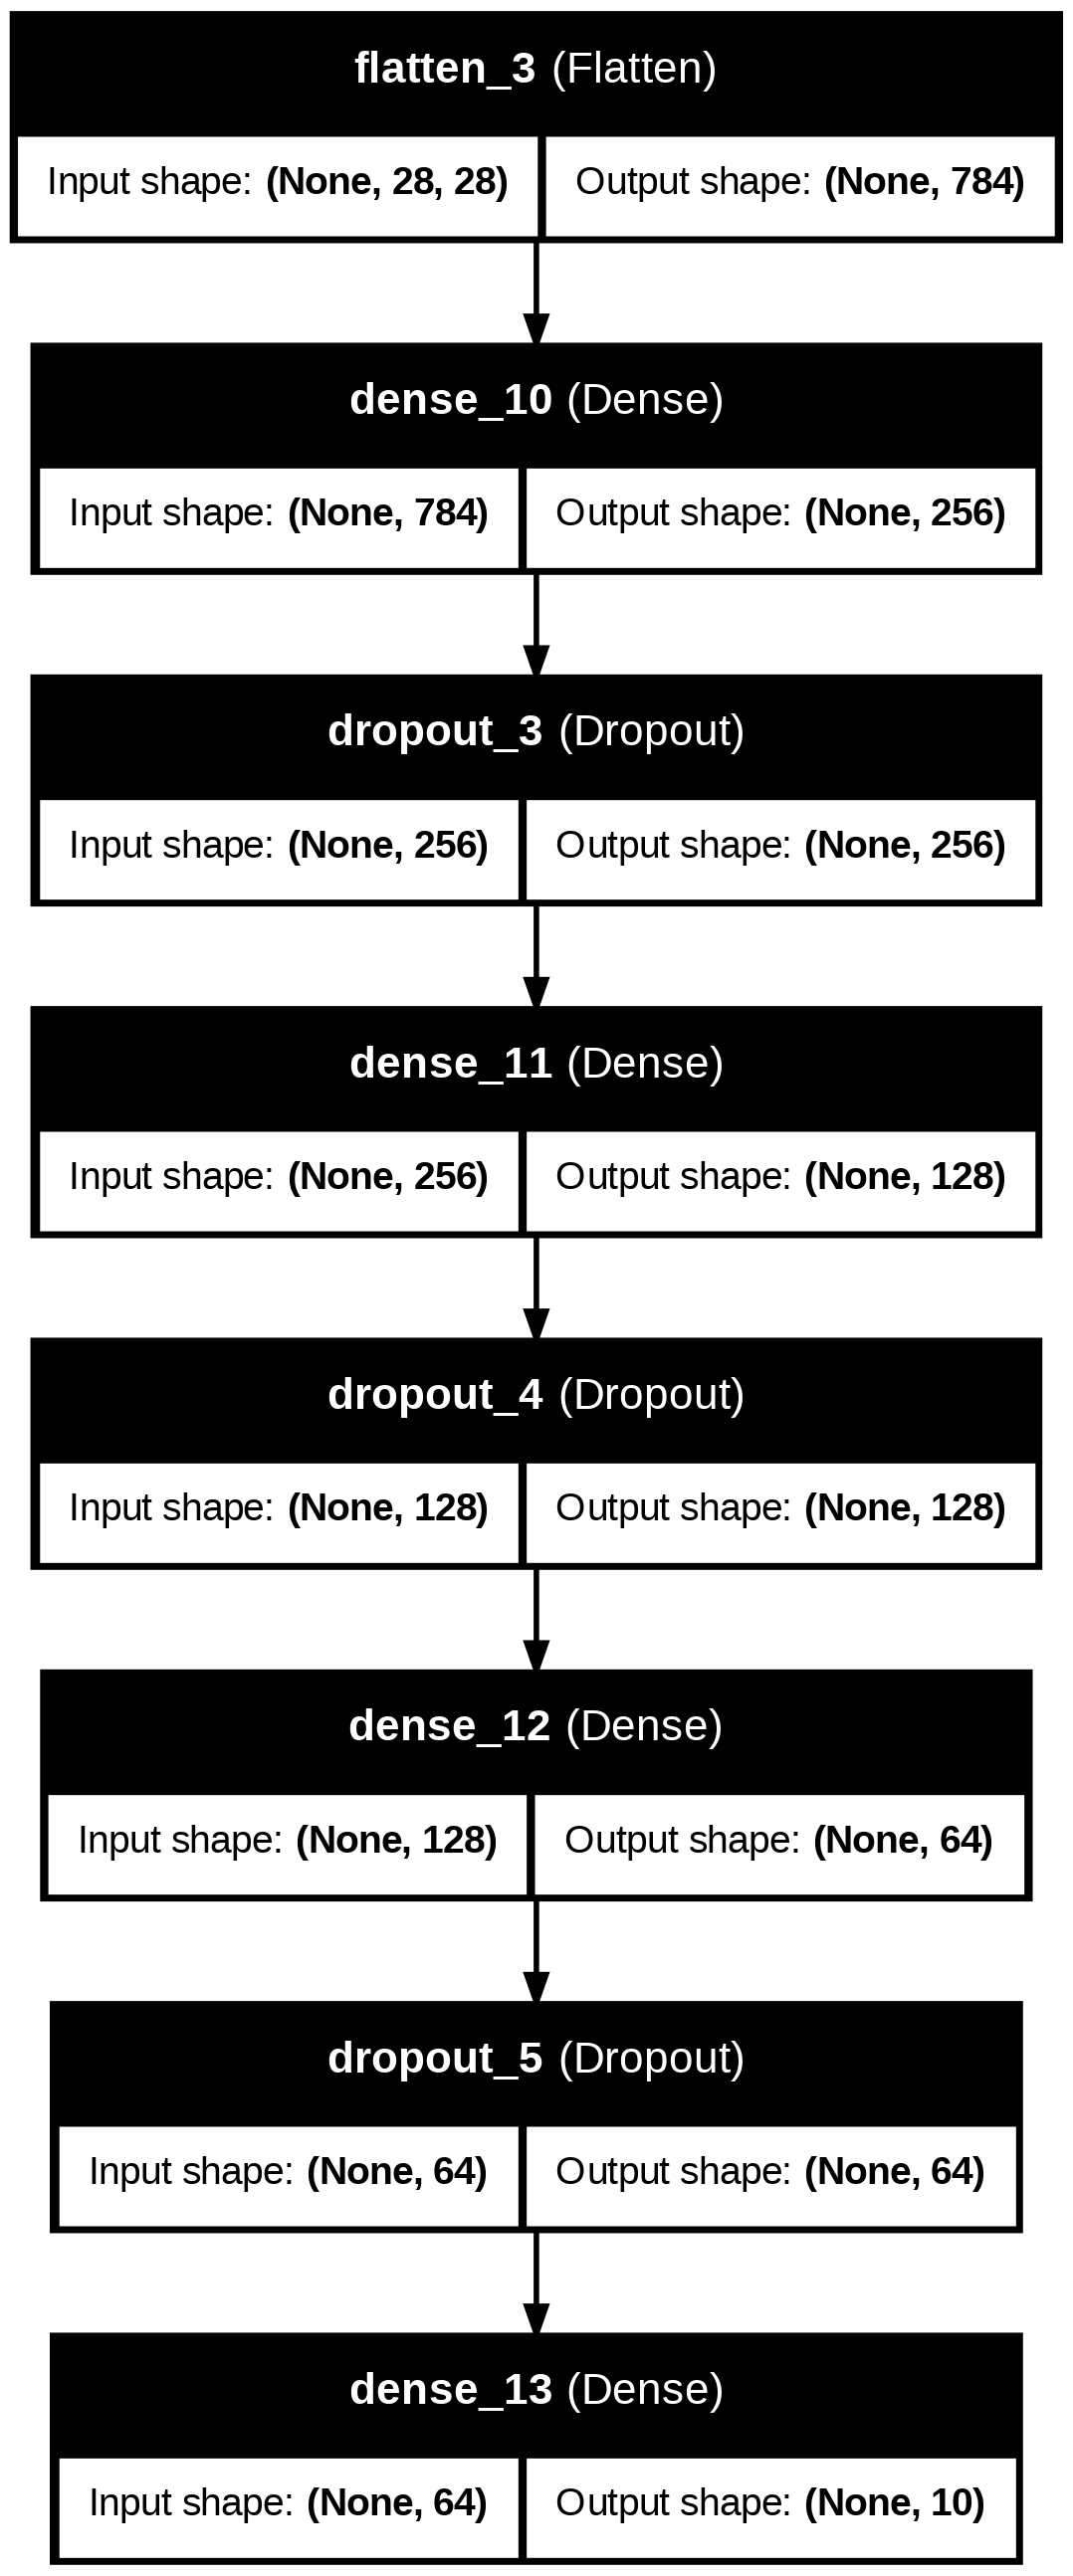

In [30]:
keras.utils.plot_model(
    final_model,
    to_file="final_model_architecture.png",
    show_shapes=True,
    show_layer_names=True)

# Fashion-MNIST Project Report

## Architecture and Design Decisions

This project developed a TensorFlow/Keras neural network for classifying Fashion-MNIST images into ten categories. The data was divided into 55,000 training images, 5,000 validation images, and 10,000 test images. Pixel values were normalized to [0, 1], and the test data was isolated until final evaluation.

The baseline consisted of a Flatten layer, one Dense hidden layer with 128 ReLU units, and a ten-unit Softmax output. ReLU provides efficient nonlinear feature learning, while Softmax produces class probabilities. Sparse categorical cross-entropy was used because the targets are integer labels. Adam was selected for optimization. All experiments used 10 epochs and a batch size of 32 to ensure comparable conditions.

Three controlled experiments were conducted. Experiment 1 increased the architecture to three hidden layers containing 256, 128, and 64 units. This increased the number of parameters from 101,770 to 242,762. Validation accuracy increased slightly from 89.46% to 89.54%, while the generalization gap increased from 1.84% to 1.95%. Therefore, the additional model capacity produced only a very small improvement while increasing computational cost and overfitting risk.

Experiment 2 added 10% Dropout after each hidden layer without changing the parameter count. It achieved 89.76% validation accuracy and a validation loss of 0.2883. Its generalization gap decreased to approximately -0.04 percentage points. The slightly negative gap indicates that validation accuracy was marginally higher than training accuracy, which can occur because Dropout is active during training but disabled during validation. This provides evidence that Dropout reduced overfitting and improved generalization.

Experiment 3 retained the regularized architecture and reduced the Adam learning rate from 0.001 to 0.0005. It achieved the highest validation accuracy of 90.02%, the lowest reported validation loss of 0.2716, and a very small final generalization gap of approximately 0.29 percentage points. The lower learning rate allowed more stable convergence and produced the strongest validation result. Experiment 3 was therefore selected as the final model.

### Training Time Comparison

Training time increased as the models became more complex. Based on the recorded epoch times, the baseline required approximately 86 seconds, Experiment 1 required 135 seconds, Experiment 2 required 146 seconds, and Experiment 3 required 130 seconds. The deeper architecture increased computational cost, while Dropout added additional training overhead. Experiment 3 produced the strongest validation result without increasing the parameter count.

## Final Evaluation and Conclusions

The final model achieved 88.68% accuracy on the untouched test set, exceeding the project target of 88%. Macro precision, recall, and F1-score were 88.73%, 88.68%, and 88.69%, respectively. The saved model produced the same evaluation result after being loaded, confirming that it was saved correctly.

The strongest classes included Trouser, Bag, Sandal, Sneaker, and Ankle boot. Shirt was the most difficult class, with an F1-score of 0.7067. Pullover, Coat, T-shirt/top, and Shirt were more difficult because they have overlapping visual features at the Fashion-MNIST resolution.

The final model did not exhibit severe overfitting. Its final training accuracy was approximately 90.31%, compared with 90.02% validation accuracy, producing a gap of approximately 0.29 percentage points. Nevertheless, test accuracy was lower than validation accuracy, showing that generalization remains imperfect.

If more time and computational resources were available, the next experiment would use a convolutional neural network. Convolutional layers can preserve spatial relationships that are lost by flattening the image and may distinguish subtle garment features more effectively. Additional tests could include data augmentation, Batch Normalization, early stopping, and learning-rate scheduling.

## Final Discussion Questions

### 1. Why did you choose this final architecture?

Experiment 3 was selected because it achieved the highest validation accuracy and the lowest validation loss among all evaluated models. It combines sufficient network capacity with Dropout regularization and a smaller learning rate, resulting in stable convergence and a small generalization gap.

### 2. What experimental evidence shows that it is better than the baseline?

The baseline achieved 89.46% validation accuracy with a generalization gap of approximately 1.84 percentage points. Experiment 3 achieved 90.02% validation accuracy with a gap of approximately 0.29 percentage points. Therefore, Experiment 3 improved validation accuracy and validation loss while substantially reducing the difference between training and validation performance.

### 3. Which classes were most difficult to distinguish, and why?

Shirt was the most difficult class, with an F1-score of 0.7067, followed by related upper-body categories such as Pullover, Coat, and T-shirt/top. These garments have similar outlines and textures, and the 28 × 28 grayscale images contain limited fine detail.

### 4. Did your model overfit?

The final model did not show severe overfitting. Its final training and validation accuracies were approximately 90.31% and 90.02%, producing a small gap of approximately 0.29 percentage points. The validation loss also reached its lowest value at the final epoch, indicating stable convergence rather than substantial overfitting.

### 5. What would you test next?

I would test a convolutional neural network because convolutional layers preserve spatial information and are more suitable for image classification. I would also evaluate data augmentation, Batch Normalization, early stopping, and an adaptive learning-rate schedule.